<a href="https://colab.research.google.com/github/somar9/Neutrino-Oscillation-Project/blob/ND-simulation---Gaussian/FDvacuum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls

Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 615, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 615 (delta 13), reused 20 (delta 10), pack-reused 586 (from 1)
Receiving objects: 100% (615/615), 764.37 KiB | 14.42 MiB/s, done.
Resolving deltas: 100% (291/291), done.
/content/NuOscProbExact/src/NuOscProbExact/src
globaldefs.py  hamiltonians2nu.py  hamiltonians3nu.py  oscprob2nu.py  oscprob3nu.py


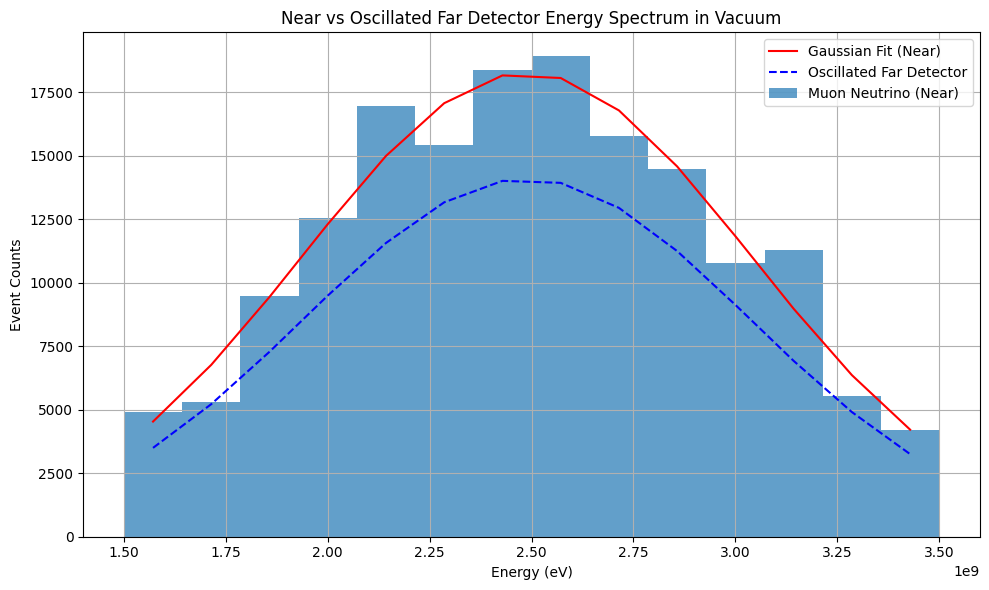

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from NuOscProbExact.src.oscprob3nu import probabilities_3nu
from NuOscProbExact.src.hamiltonians3nu import hamiltonian_3nu_vacuum_energy_independent, hamiltonian_3nu_matter
from NuOscProbExact.src.globaldefs import *

# Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Define a Gaussian energy distribution
mean_energy = 2.5e9  # Mean energy in eV (corresponds to 2.5 GeV)
sigma_energy = 0.5e9  # Standard deviation in eV
energies = np.random.normal(mean_energy, sigma_energy, 1000)

# Initialize the vacuum Hamiltonian (energy-independent part)
h_vacuum_energy_indep = hamiltonian_3nu_vacuum_energy_independent(
    S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
)

# Function to compute oscillation probabilities in a vacuum for a given baseline
def compute_probabilities_vacuum(baseline, energy_values):
    Prob_mu = []

    for E in energy_values:
        # For vacuum oscillations, no need for matter Hamiltonian
        h_vacuum = hamiltonian_3nu_vacuum_energy_independent(
            S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
        )

        # Calculate muon neutrino survival probability (Pmm) in vacuum
        _, _, _, _, Pmm, _, _, _, _ = probabilities_3nu(h_vacuum, baseline * CONV_KM_TO_INV_EV)
        Prob_mu.append(Pmm)

    return np.array(Prob_mu)

# Total number of events for near and far detectors
total_events_near = 1000

# Generate Poisson-distributed event counts based on the probabilities at the near detector
Prob_mu_near = compute_probabilities_vacuum(Length_near, energies)
counts_mu_near = np.random.poisson(lam=Prob_mu_near * total_events_near)

# Define bin edges and centers for plotting
bin_edges = np.linspace(1.5e9, 3.5e9, 15)  # Fine energy bins
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# Compute histogram for near detector using the predefined bin edges
hist_near, _ = np.histogram(energies, bins=bin_edges, weights=counts_mu_near)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Fit near detector histogram with a Gaussian
popt_near, _ = curve_fit(gaussian, bin_centers, hist_near, p0=[np.max(hist_near), mean_energy, sigma_energy])

# Oscillate near detector Gaussian to compute far detector spectrum in vacuum
oscillated_far = gaussian(bin_centers, *popt_near) * compute_probabilities_vacuum(Length_far, bin_centers)

# Plot the histograms and Gaussian fits
plt.figure(figsize=(10, 6))

# Near detector
plt.bar(bin_centers, hist_near, width=np.diff(bin_edges), align='center', alpha=0.7, label='Muon Neutrino (Near)')
plt.plot(bin_centers, gaussian(bin_centers, *popt_near), 'r-', label='Gaussian Fit (Near)')

# Oscillated Far detector in vacuum
plt.plot(bin_centers, oscillated_far, 'b--', label='Oscillated Far Detector')

plt.xlabel('Energy (eV)')
plt.ylabel('Event Counts')
plt.title('Near vs Oscillated Far Detector Energy Spectrum in Vacuum')

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


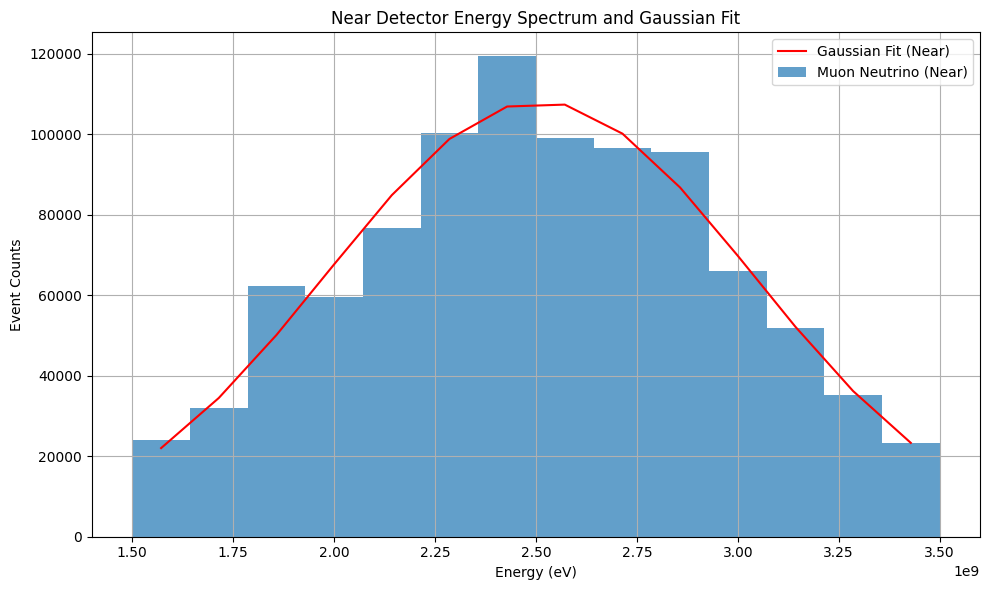

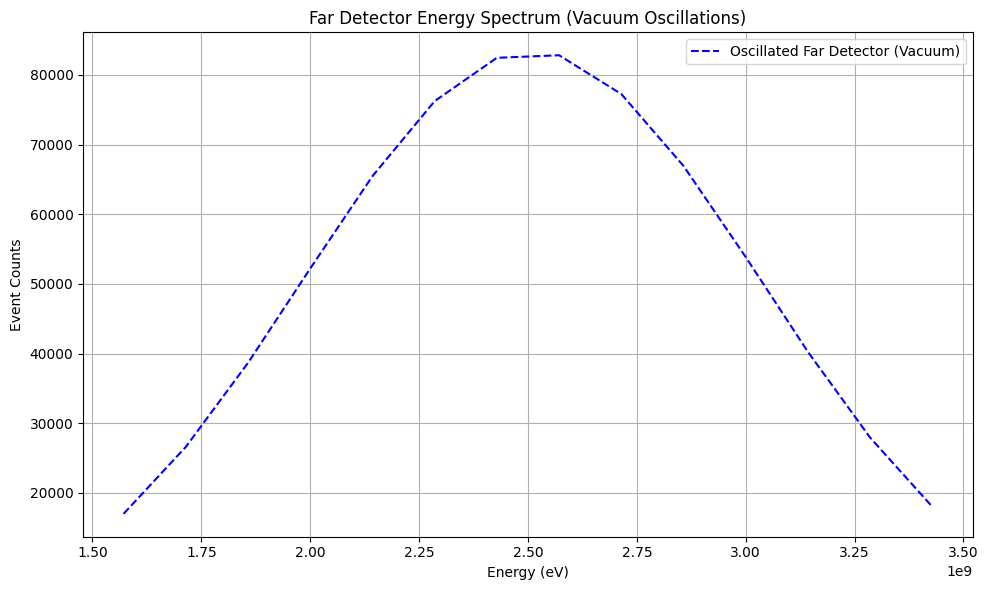

In [31]:
# Plot the histograms and Gaussian fits for the near detector
plt.figure(figsize=(10, 6))

# Near detector
plt.bar(bin_centers, hist_near, width=np.diff(bin_edges), align='center', alpha=0.7, label='Muon Neutrino (Near)')
plt.plot(bin_centers, gaussian(bin_centers, *popt_near), 'r-', label='Gaussian Fit (Near)')
plt.xlabel('Energy (eV)')
plt.ylabel('Event Counts')
plt.title('Near Detector Energy Spectrum and Gaussian Fit')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Plot the oscillated far detector (vacuum oscillations)
plt.figure(figsize=(10, 6))
plt.plot(bin_centers, oscillated_far_vacuum, 'b--', label='Oscillated Far Detector (Vacuum)')
plt.xlabel('Energy (eV)')
plt.ylabel('Event Counts')
plt.title('Far Detector Energy Spectrum (Vacuum Oscillations)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


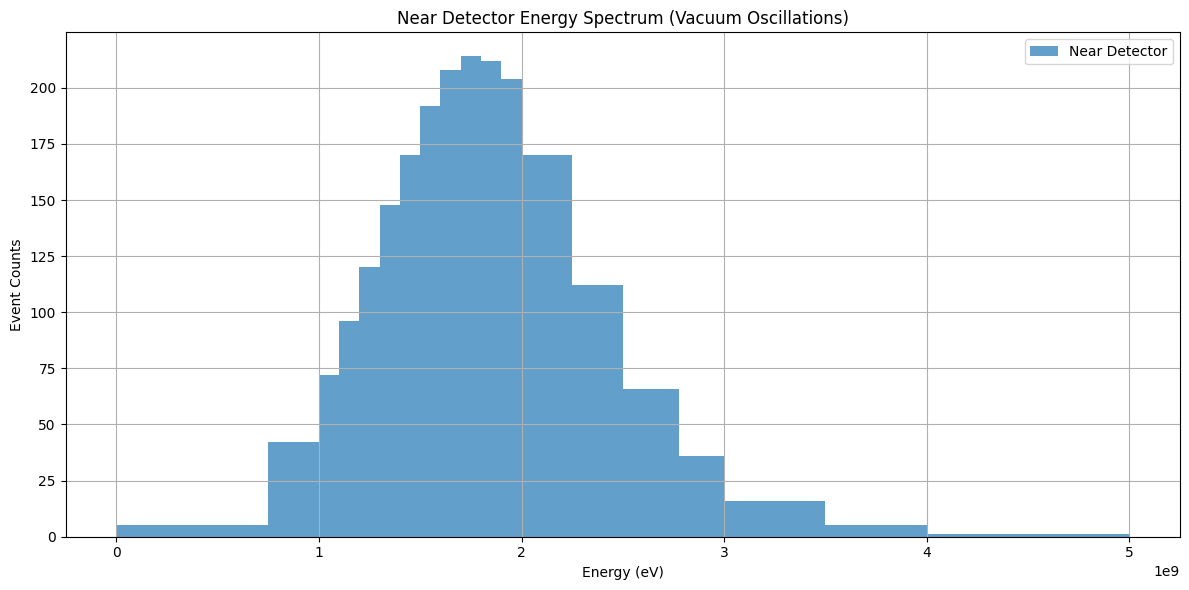

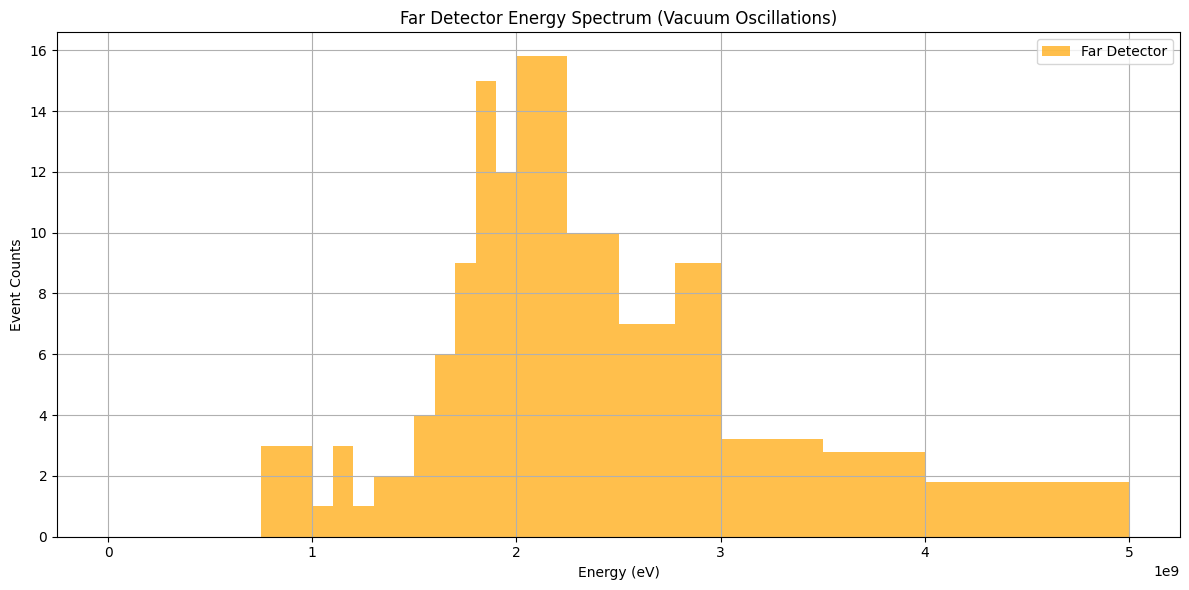

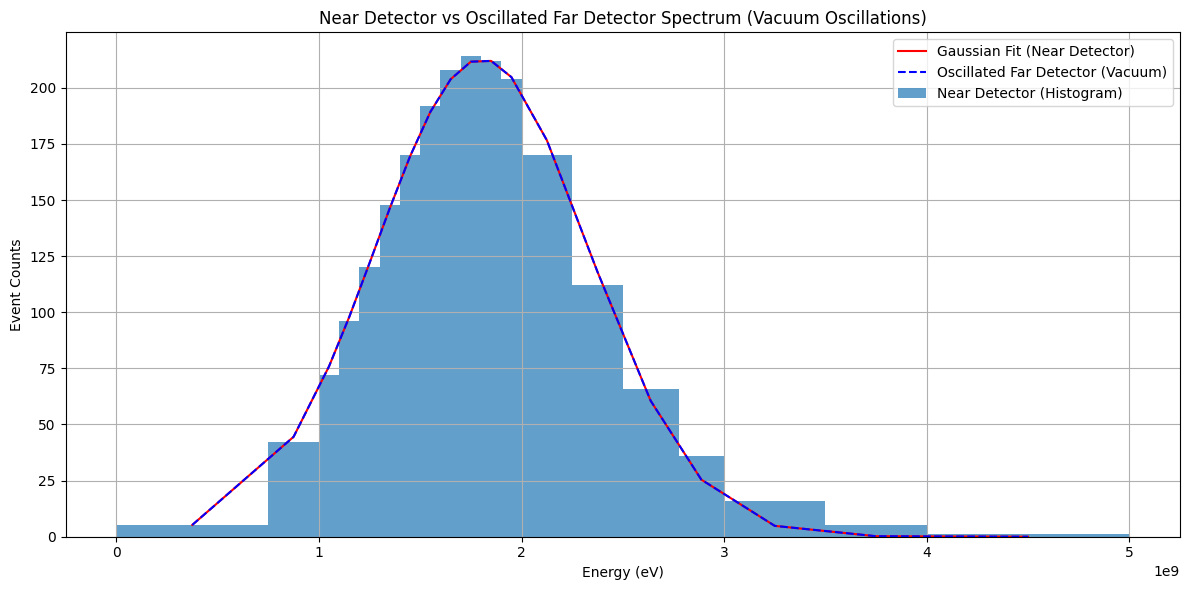

In [32]:
# Given Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9  # eV
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # eV
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

# Detector Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Initialize the vacuum Hamiltonian
h_vacuum_energy_indep = hamiltonian_3nu_vacuum_energy_independent(
    S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
)

# Function to compute oscillation probabilities in vacuum for muon neutrinos
def compute_probabilities_vacuum(baseline, energy_values):
    Prob_mu = []
    for E in energy_values:
        h_vacuum = hamiltonian_3nu_vacuum_energy_independent(
            S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
        )
        _, _, _, _, Pmm, _, _, _, _ = probabilities_3nu(h_vacuum, baseline * CONV_KM_TO_INV_EV)
        Prob_mu.append(Pmm)
    return np.array(Prob_mu)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Fit the near detector data with a Gaussian
popt_nd, _ = curve_fit(
    gaussian,
    bin_centers,
    counts_nd,
    p0=[np.max(counts_nd), 2.5e9, 0.5e9]
)

# Compute oscillation probabilities for the far detector (vacuum)
Prob_mu_far = compute_probabilities_vacuum(Length_far, bin_centers)

# Oscillated far detector spectrum (apply oscillation to fitted Gaussian)
oscillated_fd_vacuum = gaussian(bin_centers, *popt_nd) * Prob_mu_far / np.max(Prob_mu_far)

# Plotting Near Detector Histogram
plt.figure(figsize=(12, 6))
plt.bar(bin_centers, counts_nd, width=np.diff(bin_edges), align='center', alpha=0.7, label='Near Detector')
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector Energy Spectrum (Vacuum Oscillations)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Plotting Far Detector Histogram (Original Data)
plt.figure(figsize=(12, 6))
plt.bar(bin_centers, counts_fd, width=np.diff(bin_edges), align='center', alpha=0.7, label='Far Detector', color='orange')
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Far Detector Energy Spectrum (Vacuum Oscillations)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Plot Near Detector and Oscillated Far Detector Histograms (Vacuum Oscillations)
plt.figure(figsize=(12, 6))

# Near Detector (Histogram and Gaussian Fit)
plt.bar(
    bin_centers,
    counts_nd,
    width=np.diff(bin_edges),
    align="center",
    alpha=0.7,
    label="Near Detector (Histogram)"
)
plt.plot(
    bin_centers,
    gaussian(bin_centers, *popt_nd),
    "r-",
    label="Gaussian Fit (Near Detector)"
)

# Oscillated Far Detector
plt.plot(
    bin_centers,
    oscillated_fd_vacuum,
    "b--",
    label="Oscillated Far Detector (Vacuum)"
)

# Plot settings
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum (Vacuum Oscillations)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

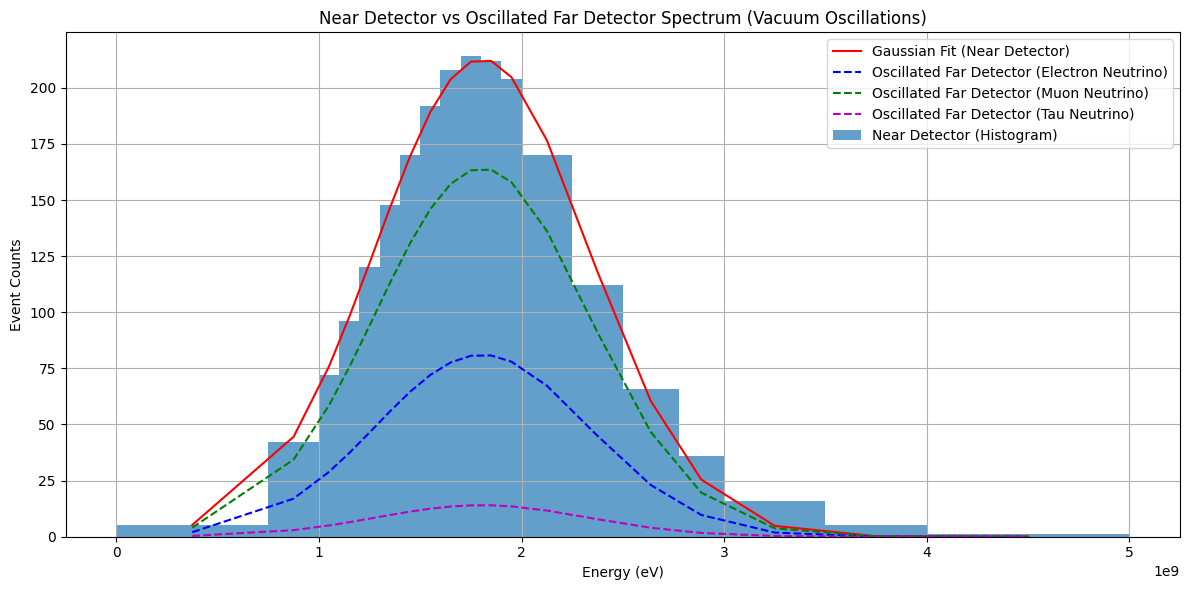

In [36]:
# Function to compute oscillation probabilities for all flavors in vacuum
def compute_probabilities_all_flavors_vacuum(baseline, energy_values):
    Prob_e, Prob_mu, Prob_tau = [], [], []
    for E in energy_values:
        h_vacuum = hamiltonian_3nu_vacuum_energy_independent(
            S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
        )
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(h_vacuum, baseline * CONV_KM_TO_INV_EV)

        Prob_e.append(Pee)  # Electron neutrino survival (should be highest)
        Prob_mu.append(Pmm)  # Muon neutrino survival
        Prob_tau.append(Pmt)  # Tau neutrino survival
    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute oscillation probabilities for all flavors at the far detector (vacuum)
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities_all_flavors_vacuum(Length_far, bin_centers)

# Generate oscillated far detector spectra for all flavors (vacuum)
oscillated_fd_e = gaussian(bin_centers, *popt_nd) * Prob_e_far
oscillated_fd_mu = gaussian(bin_centers, *popt_nd) * Prob_mu_far
oscillated_fd_tau = gaussian(bin_centers, *popt_nd) * Prob_tau_far

# Plot Near Detector and Oscillated Far Detector Histograms (Vacuum)
plt.figure(figsize=(12, 6))

# Near Detector (Histogram and Gaussian Fit)
plt.bar(
    bin_centers,
    counts_nd,
    width=np.diff(bin_edges),
    align="center",
    alpha=0.7,
    label="Near Detector (Histogram)"
)
plt.plot(
    bin_centers,
    gaussian(bin_centers, *popt_nd),
    "r-",
    label="Gaussian Fit (Near Detector)"
)

# Oscillated Far Detector for all flavors (Vacuum)
plt.plot(
    bin_centers,
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers,
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers,
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)

# Plot settings
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum (Vacuum Oscillations)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


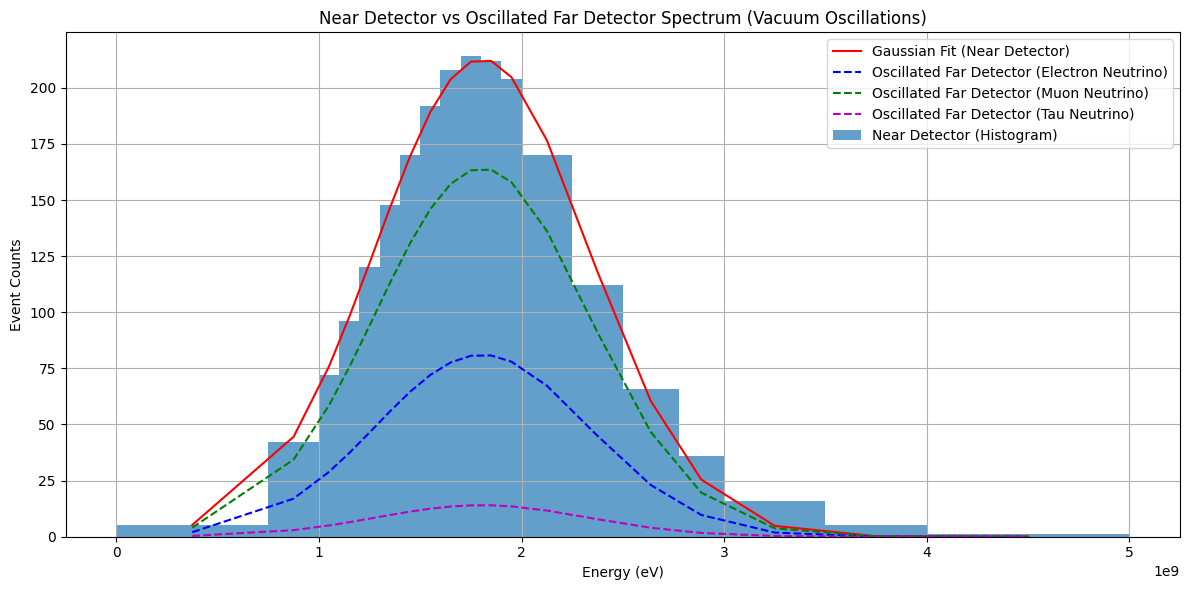

In [38]:
# Function to compute oscillation probabilities for all flavors in vacuum
def compute_probabilities_all_flavors_vacuum(baseline, energy_values):
    Prob_e, Prob_mu, Prob_tau = [], [], []
    for E in energy_values:
        # Set the Hamiltonian for vacuum oscillations
        h_vacuum = hamiltonian_3nu_vacuum_energy_independent(
            S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
        )

        # Calculate the 3-flavor oscillation probabilities
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(h_vacuum, baseline * CONV_KM_TO_INV_EV)

        # Ensure each flavor's survival probability is assigned correctly
        Prob_e.append(Pee)  # Electron neutrino survival (should be highest)
        Prob_mu.append(Pmm)  # Muon neutrino survival (less than electron)
        Prob_tau.append(Pmt)  # Tau neutrino survival (should be the lowest)

    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute oscillation probabilities for all flavors at the far detector (vacuum)
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities_all_flavors_vacuum(Length_far, bin_centers)

# Generate oscillated far detector spectra for all flavors (vacuum)
oscillated_fd_e = gaussian(bin_centers, *popt_nd) * Prob_e_far
oscillated_fd_mu = gaussian(bin_centers, *popt_nd) * Prob_mu_far
oscillated_fd_tau = gaussian(bin_centers, *popt_nd) * Prob_tau_far

# Plot Near Detector and Oscillated Far Detector Histograms (Vacuum)
plt.figure(figsize=(12, 6))

# Near Detector (Histogram and Gaussian Fit)
plt.bar(
    bin_centers,
    counts_nd,
    width=np.diff(bin_edges),
    align="center",
    alpha=0.7,
    label="Near Detector (Histogram)"
)
plt.plot(
    bin_centers,
    gaussian(bin_centers, *popt_nd),
    "r-",
    label="Gaussian Fit (Near Detector)"
)

# Oscillated Far Detector for all flavors (Vacuum)
plt.plot(
    bin_centers,
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers,
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers,
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)

# Plot settings
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum (Vacuum Oscillations)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
